In [ ]:
import pandas as pd
import glob
import re
import os

# Ruta de la carpeta con las medidas del día
carpeta = "datos 2026-08-13"

dataFrames_datos = {}
posiciones = []

archivos = glob.glob(os.path.join(carpeta, "z*mm.xlsx"))

for archivo in archivos:
    nombre = os.path.basename(archivo)  # solo el nombre, sin la ruta
    match = re.search(r"z(\d+)mm\.xlsx", nombre)
    if match:
        posicion = float(match.group(1))
        posiciones.append(posicion)

        df = pd.read_excel(archivo, skiprows=21)
        dataFrames_datos[posicion] = df

posiciones = sorted(posiciones)
print("Posiciones encontradas:", posiciones)

Posiciones encontradas: []


In [1]:
import os
import glob

carpeta = "datos 2026-08-13"

print("Directorio actual:", os.getcwd())
print("¿Existe la carpeta?:", os.path.exists(carpeta))
print("Contenido de la carpeta:", os.listdir(carpeta) if os.path.exists(carpeta) else "No existe")

archivos = glob.glob(os.path.join(carpeta, "*.xlsx"))
print("Archivos .xlsx encontrados (cualquier nombre):", archivos)

Directorio actual: c:\Users\13\Documents\repositorio optica\optica
¿Existe la carpeta?: True
Contenido de la carpeta: ['.git', 'z0mm.xlsx', 'z100mm.xlsx', 'z125mm.xlsx', 'z150mm.xlsx', 'z175mm.xlsx', 'z200mm.xlsx', 'z225mm.xlsx', 'z250mm.xlsx', 'z25mm.xlsx', 'z275mm.xlsx', 'z50mm.xlsx', 'z75mm.xlsx', '~$z0mm.xlsx']
Archivos .xlsx encontrados (cualquier nombre): ['datos 2026-08-13\\z0mm.xlsx', 'datos 2026-08-13\\z100mm.xlsx', 'datos 2026-08-13\\z125mm.xlsx', 'datos 2026-08-13\\z150mm.xlsx', 'datos 2026-08-13\\z175mm.xlsx', 'datos 2026-08-13\\z200mm.xlsx', 'datos 2026-08-13\\z225mm.xlsx', 'datos 2026-08-13\\z250mm.xlsx', 'datos 2026-08-13\\z25mm.xlsx', 'datos 2026-08-13\\z275mm.xlsx', 'datos 2026-08-13\\z50mm.xlsx', 'datos 2026-08-13\\z75mm.xlsx', 'datos 2026-08-13\\~$z0mm.xlsx']


In [8]:
import pandas as pd
import numpy as np
import glob
import re
import os

# ============================================================
# PARÁMETROS
# ============================================================
I_sat = 1.1  # mW/cm^2 -- intensidad de saturación transición F4->F5 del Cs
N = 20   # Número de datos tomados (ajustado en el logsetup)
carpeta = "datos 2026-08-13"

# ============================================================
# LECTURA DE ARCHIVOS (lo que ya tenías)
# ============================================================
dataFrames_datos = {}
posiciones = []

archivos = [a for a in glob.glob(os.path.join(carpeta, "z*mm.xlsx"))
            if not os.path.basename(a).startswith("~$")]

for archivo in archivos:
    nombre = os.path.basename(archivo)
    match = re.search(r"z(\d+)mm\.xlsx", nombre)
    if match:
        posicion = float(match.group(1))
        posiciones.append(posicion)

        df = pd.read_excel(archivo, skiprows=21)
        dataFrames_datos[posicion] = df.iloc[:N+1]

posiciones = sorted(posiciones)
print("Posiciones encontradas:", posiciones)

# ============================================================
# CÁLCULO DE INTENSIDAD PARA CADA ARCHIVO
# ============================================================
resultados = []

for pos in posiciones:
    df = dataFrames_datos[pos]

    # --- Potencia promedio (mW) ---
    P_mean = df['Power'].mean()
    P_std = df['Power'].std()

    # --- Anchos promedio del haz (en micrones) ---
    # Asumimos que son DIÁMETROS a 1/e^2. Si tu equipo da el RADIO,
    # elimina la división entre 2 en w_x y w_y.
    d_x = df['W GaussWidth I'].mean()
    d_y = df['V GaussWidth I'].mean()

    w_x = d_x / 2   # radio horizontal [micron]
    w_y = d_y / 2   # radio vertical   [micron]

    # --- Conversión de micrones a cm ---
    w_x_cm = w_x * 1e-4
    w_y_cm = w_y * 1e-4

    # --- Área efectiva del haz elíptico Gaussiano (cm^2) ---
    A_cm2 = np.pi * w_x_cm * w_y_cm

    # --- Intensidad (mW/cm^2) ---
    I = P_mean / A_cm2

    # --- Razón respecto a la intensidad de saturación ---
    I_over_Isat = I / I_sat

    resultados.append({
        'Posicion_z_mm': pos,
        'Potencia_mW': P_mean,
        'Potencia_std_mW': P_std,
        'Diametro_x_um': d_x,
        'Diametro_y_um': d_y,
        'Area_cm2': A_cm2,
        'Intensidad_mW_cm2': I,
        'I/Isat': I_over_Isat
    })

# ============================================================
# RESULTADOS EN TABLA
# ============================================================
df_resultados = pd.DataFrame(resultados)
df_resultados = df_resultados.sort_values('Posicion_z_mm').reset_index(drop=True)

print(df_resultados.to_string(index=False))

# Guardar resultados
df_resultados.to_excel(os.path.join(carpeta, "resultados_intensidad.xlsx"), index=False)

Posiciones encontradas: [0.0, 25.0, 50.0, 75.0, 100.0, 125.0, 150.0, 175.0, 200.0, 225.0, 250.0, 275.0]


KeyError: 'Power'

In [10]:
df_raw = pd.read_excel(os.path.join(carpeta, "z0mm.xlsx"), header=None)
print(df_raw.head(25))

                                                   0                    1   \
0   *** BeamMaster USB Measurement system, Version...                  NaN   
1                                                 NaN                  NaN   
2                                                 NaN                  NaN   
3                                               File:            z0mm.xlsx   
4                                               Date:  2026-08-13 00:00:00   
5                                               Time:             11:33:28   
6                                                 NaN                  NaN   
7                                                S/N:               BM4987   
8                                                 NaN                  NaN   
9                                            Average:                  OFF   
10                                                NaN                  NaN   
11                                        Wavelength:           

Encontrados 12 archivos para procesar.
Resultados guardados en: datos 2026-08-13\resultados_intensidad.xlsx
    z (mm)  Intensidad (mW/cm^2)    I/I_sat
0      0.0             13.790025  12.536387
8     25.0             13.988641  12.716946
10    50.0             14.486027  13.169116
11    75.0             14.685275  13.350250
1    100.0             15.265159  13.877417
2    125.0             16.116407  14.651279
3    150.0             16.572487  15.065897
4    175.0             17.160264  15.600240
5    200.0             17.142863  15.584421
6    225.0             16.874119  15.340108
7    250.0             17.035312  15.486647
9    275.0             17.498745  15.907950


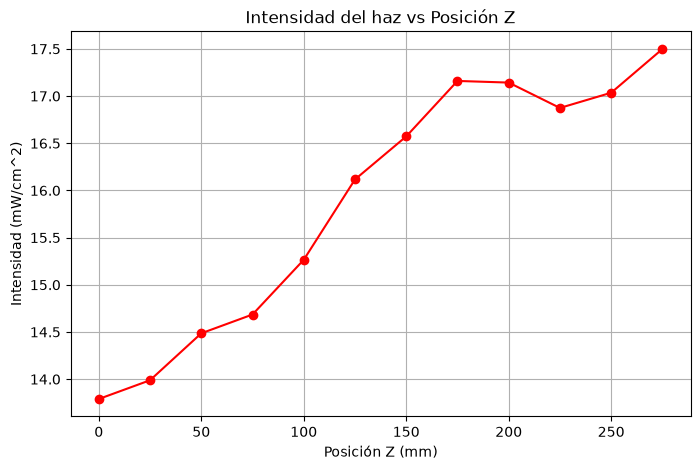

In [11]:
import pandas as pd
import numpy as np
import glob
import re
import os
import matplotlib.pyplot as plt

def procesar_escaneo_laser(folder_path):
    """
    Lee archivos Excel de un Beam Profiler, calcula promedios y parámetros 
    de intensidad, y exporta un resumen.
    """
    resultados = []
    
    # 1. Buscar archivos "z*mm.xlsx" y filtrar temporales
    archivos = [f for f in glob.glob(os.path.join(folder_path, 'z*mm.xlsx')) 
                if not os.path.basename(f).startswith('~$')]
    
    # Expresión regular para extraer la posición Z
    regex = re.compile(r'z(\d+)mm\.xlsx')
    
    print(f"Encontrados {len(archivos)} archivos para procesar.")

    for archivo in archivos:
        match = regex.search(os.path.basename(archivo))
        if not match:
            continue
        
        z_pos = float(match.group(1))
        
        # 2. Leer archivo: saltar 21 filas (metadata + encabezados), 
        # usar decimal ',' para convertir automáticamente a float.
        # Las columnas se definen explícitamente dado el formato conocido.
        columnas = ['Time', 'Power', 'Pos.X', 'Pos.Y', 'W Width I', 'W Width II', 
                    'V Width I', 'V Width II', 'Major', 'Minor', 'W Correlation', 
                    'V Correlation', 'W GaussWidth I', 'V GaussWidth I']
        
        df = pd.read_excel(archivo, skiprows=22, names=columnas, decimal=',')
        
        # 3. Cálculos físicos
        # Potencia promedio y std
        p_avg = df['Power'].mean()
        p_std = df['Power'].std()
        
        # Radios en cm (1 micra = 1e-4 cm, diámetro/2 = radio)
        w_x = (df['W GaussWidth I'].mean() / 2) * 1e-4
        w_y = (df['V GaussWidth I'].mean() / 2) * 1e-4
        
        # Área elíptica A = pi * wx * wy (cm^2)
        area = np.pi * w_x * w_y
        
        # Intensidad I = P / A (mW/cm^2)
        intensidad = p_avg / area if area > 0 else 0
        
        # I/I_sat (I_sat = 1.1 mW/cm^2)
        i_sat = 1.1
        razon_sat = intensidad / i_sat
        
        resultados.append({
            'z (mm)': z_pos,
            'Potencia (mW)': p_avg,
            'std_Power': p_std,
            'Radio X (cm)': w_x,
            'Radio Y (cm)': w_y,
            'Área (cm^2)': area,
            'Intensidad (mW/cm^2)': intensidad,
            'I/I_sat': razon_sat
        })

    # 4. Crear DataFrame ordenado y exportar
    df_final = pd.DataFrame(resultados).sort_values(by='z (mm)')
    
    output_path = os.path.join(folder_path, 'resultados_intensidad.xlsx')
    df_final.to_excel(output_path, index=False)
    
    print(f"Resultados guardados en: {output_path}")
    return df_final

# --- Ejecución y Graficación ---
folder = 'datos 2026-08-13'
if os.path.exists(folder):
    df_resultados = procesar_escaneo_laser(folder)
    print(df_resultados[['z (mm)', 'Intensidad (mW/cm^2)', 'I/I_sat']])
    
    # 5. Gráfico de Intensidad vs Z
    plt.figure(figsize=(8, 5))
    plt.plot(df_resultados['z (mm)'], df_resultados['Intensidad (mW/cm^2)'], 'o-r')
    plt.xlabel('Posición Z (mm)')
    plt.ylabel('Intensidad (mW/cm^2)')
    plt.title('Intensidad del haz vs Posición Z')
    plt.grid(True)
    plt.show()
else:
    print(f"Error: La carpeta '{folder}' no existe.")

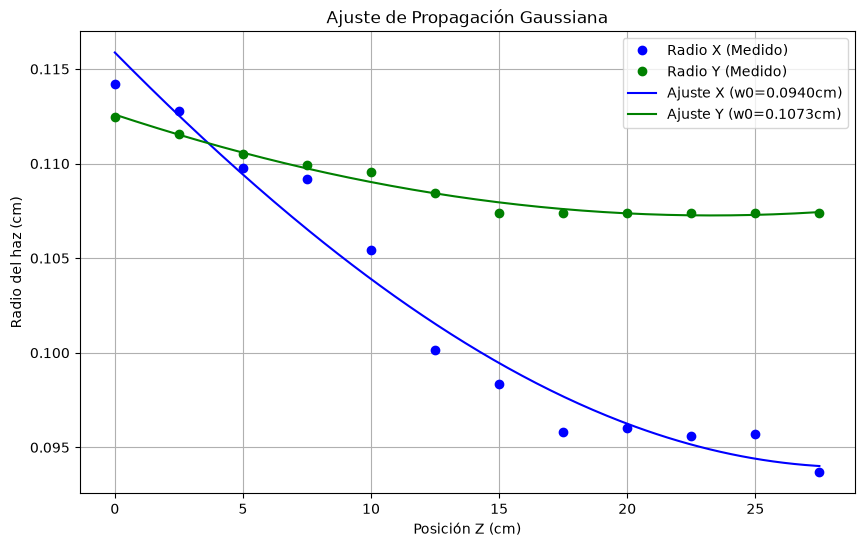

In [14]:
import pandas as pd
import numpy as np
from scipy.optimize import curve_fit
import matplotlib.pyplot as plt

# 1. Definir la función de propagación del haz Gaussiano
def beam_width_func(z, w0, z0, zR):
    """
    z: posición axial
    w0: radio en la cintura
    z0: posición de la cintura
    zR: Rango de Rayleigh
    """
    return w0 * np.sqrt(1 + ((z - z0) / zR)**2)

def analizar_propagacion(df):
    # Convertimos de mm (del perfilador) a cm (para el ajuste)
    z_cm = df['z (mm)'].values / 10.0
    wx = df['Radio X (cm)'].values
    wy = df['Radio Y (cm)'].values
    
    # Estimaciones iniciales para el algoritmo (guesses)
    # w0 ≈ el valor mínimo medido, z0 ≈ la posición del mínimo, zR ≈ 1 cm (ejemplo)
    p0 = [min(wx), z_cm[np.argmin(wx)], 1.0]
    
    # 2. Realizar ajuste no lineal
    popt_x, _ = curve_fit(beam_width_func, z_cm, wx, p0=p0)
    popt_y, _ = curve_fit(beam_width_func, z_cm, wy, p0=p0)
    
    # 3. Graficar resultados
    z_fit = np.linspace(min(z_cm), max(z_cm), 200)
    
    plt.figure(figsize=(10, 6))
    plt.plot(z_cm, wx, 'bo', label='Radio X (Medido)')
    plt.plot(z_cm, wy, 'go', label='Radio Y (Medido)')
    plt.plot(z_fit, beam_width_func(z_fit, *popt_x), 'b-', label=f'Ajuste X (w0={popt_x[0]:.4f}cm)')
    plt.plot(z_fit, beam_width_func(z_fit, *popt_y), 'g-', label=f'Ajuste Y (w0={popt_y[0]:.4f}cm)')
    
    plt.xlabel('Posición Z (cm)')
    plt.ylabel('Radio del haz (cm)')
    plt.title('Ajuste de Propagación Gaussiana')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    return popt_x, popt_y

# --- Cómo usarlo después de tener tu df_resultados ---
popt_x, popt_y = analizar_propagacion(df_resultados)

# --- Para obtener la intensidad en una posición Z específica (ej. z_celda = 27.5 cm) ---
def calcular_intensidad_en_z(z_celda_cm, P_avg, popt_x, popt_y):
    wx_z = beam_width_func(z_celda_cm, *popt_x)
    wy_z = beam_width_func(z_celda_cm, *popt_y)
    area = np.pi * wx_z * wy_z
    intensidad = P_avg / area
    return intensidad

# Ejemplo: intensidad_celda = calcular_intensidad_en_z(27.5, P_promedio, popt_x, popt_y)
# print(f"Intensidad estimada en la celda: {intensidad_celda:.2f} mW/cm^2")